In [2]:
import sys
print(f"Python version: {sys.version}")
print(f"Python executable: {sys.executable}")

try:
    import pandas as pd
    import numpy as np
    import seaborn as sns
    print("All imports successful!")
    print(f"Pandas version: {pd.__version__}")
    print(f"NumPy version: {np.__version__}")
except Exception as e:
    print(f"Import error: {e}")


Python version: 3.11.5 (tags/v3.11.5:cce6ba9, Aug 24 2023, 14:38:34) [MSC v.1936 64 bit (AMD64)]
Python executable: c:\Github\timeseries-vision-recommender-\venv\Scripts\python.exe
All imports successful!
Pandas version: 2.3.1
NumPy version: 2.2.6


#Análisis Exploratorio de Datos (EDA)

In [5]:
import matplotlib.pyplot as plt
import os

# Opción 1: Ruta relativa corregida (desde NOTEBOOK hacia DATA)
try:
    df_users = pd.read_csv("../DATA/Final_Updated_Expanded_Users.csv")
    df_history = pd.read_csv("../DATA/Final_Updated_Expanded_UserHistory.csv")
    df_reviews = pd.read_csv("../DATA/Final_Updated_Expanded_Reviews.csv")
    print(" Archivos cargados exitosamente con ruta relativa")
except FileNotFoundError as e:
    print(f" Error con ruta relativa: {e}")
    
    # Opción 2: Ruta absoluta
    try:
        base_path = r"C:\Github\timeseries-vision-recommender-\Modulo 3\DATA"
        df_users = pd.read_csv(os.path.join(base_path, "Final_Updated_Expanded_Users.csv"))
        df_history = pd.read_csv(os.path.join(base_path, "Final_Updated_Expanded_UserHistory.csv"))
        df_reviews = pd.read_csv(os.path.join(base_path, "Final_Updated_Expanded_Reviews.csv"))
        print(" Archivos cargados exitosamente con ruta absoluta")
    except FileNotFoundError as e:
        print(f" Error con ruta absoluta: {e}")
        
        # Opción 3: Cambiar directorio de trabajo
        try:
            os.chdir(r"C:\Github\timeseries-vision-recommender-\Modulo 3")
            df_users = pd.read_csv("DATA/Final_Updated_Expanded_Users.csv")
            df_history = pd.read_csv("DATA/Final_Updated_Expanded_UserHistory.csv")
            df_reviews = pd.read_csv("DATA/Final_Updated_Expanded_Reviews.csv")
            print(" Archivos cargados exitosamente cambiando directorio")
        except FileNotFoundError as e:
            print(f" Error cambiando directorio: {e}")


 Archivos cargados exitosamente con ruta relativa


In [ ]:
df_users.head()

,UserID,Name,Email,Preferences,Gender,NumberOfAdults,NumberOfChildren
0,1,Kavya,kavya@example.com,"Beaches, Historical",Female,1,0
1,2,Rohan,rohan@example.com,"Nature, Adventure",Male,2,2
2,3,Kavya,kavya@example.com,"City, Historical",Female,2,0
3,4,Anika,anika@example.com,"Beaches, Historical",Female,1,0
4,5,Tanvi,tanvi@example.com,"Nature, Adventure",Female,2,2


In [ ]:
df_dest.head()

,DestinationID,Name,State,Type,Popularity,BestTimeToVisit
0,1,Taj Mahal,Uttar Pradesh,Historical,8.691906,Nov-Feb
1,2,Goa Beaches,Goa,Beach,8.605032,Nov-Mar
2,3,Jaipur City,Rajasthan,City,9.225372,Oct-Mar
3,4,Kerala Backwaters,Kerala,Nature,7.977386,Sep-Mar
4,5,Leh Ladakh,Jammu and Kashmir,Adventure,8.399822,Apr-Jun


In [ ]:
df_history.head()

,HistoryID,UserID,DestinationID,VisitDate,ExperienceRating
0,1,525,760,2024-01-01,3
1,2,184,532,2024-02-15,5
2,3,897,786,2024-03-20,2
3,4,470,660,2024-01-01,1
4,5,989,389,2024-02-15,4


In [ ]:
df_reviews

,ReviewID,DestinationID,UserID,Rating,ReviewText
0,1,178,327,2,Incredible monument!
1,2,411,783,1,Loved the beaches!
2,3,927,12,2,A historical wonder
3,4,358,959,3,Incredible monument!
4,5,989,353,2,Loved the beaches!
...,...,...,...,...,...
994,995,231,346,5,Loved the beaches!
995,996,140,140,3,A historical wonder
996,997,823,858,5,Incredible monument!
997,998,279,839,2,Loved the beaches!


Los conjuntos de datos contienen las siguientes tablas:
Usuarios (999 filas): Datos demográficos y preferencias, con columnas UserID, Name, Email, Preferences, Gender, NumberOfAdults, NumberOfChildren.

Historial de usuarios (999 filas): Historial de viajes, con UserID, DestinationID, VisitDate, ExperienceRating.

Reseñas (999 filas): Reseñas de destinos, con UserID, DestinationID, Rating, ReviewText.

Destinos (1000 filas): Información de destinos, con DestinationID, Name, State, Type, Popularity, BestTimeToVisit.

## Estadísticas descriptivas de Usuarios

In [ ]:
# Resumen estadístico de usuarios
print(df_users[['Gender','NumberOfAdults','NumberOfChildren']].describe())
print("\nPreferencias únicas:", df_users['Preferences'].unique())
print("\nDistribución por género:\n", df_users['Gender'].value_counts())
print("\nTop 5 nombres de usuario más frecuentes:\n", df_users['Name'].value_counts().head())


       NumberOfAdults  NumberOfChildren
count      999.000000        999.000000
mean         1.504505          0.981982
std          0.500230          0.811784
min          1.000000          0.000000
25%          1.000000          0.000000
50%          2.000000          1.000000
75%          2.000000          2.000000
max          2.000000          2.000000

Preferencias únicas: ['Beaches, Historical' 'Nature, Adventure' 'City, Historical']

Distribución por género:
 Gender
Male      503
Female    496
Name: count, dtype: int64

Top 5 nombres de usuario más frecuentes:
 Name
Aanya     64
Riya      59
Meera     56
Aarav     55
Hitesh    54
Name: count, dtype: int64


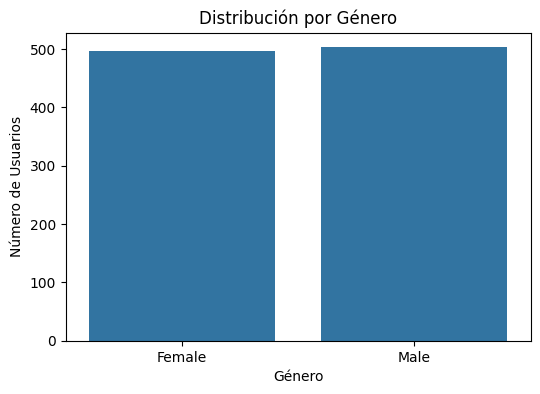

In [ ]:


# Distribución de género
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df_users)
plt.title('Distribución por Género')
plt.xlabel('Género')
plt.ylabel('Número de Usuarios')
plt.show()



La base de usuarios está prácticamente equilibrada por género (≈50 % mujeres vs. 50 % hombres), por lo que tu sistema de recomendación no necesitará ajustes específicos para un sesgo de género.

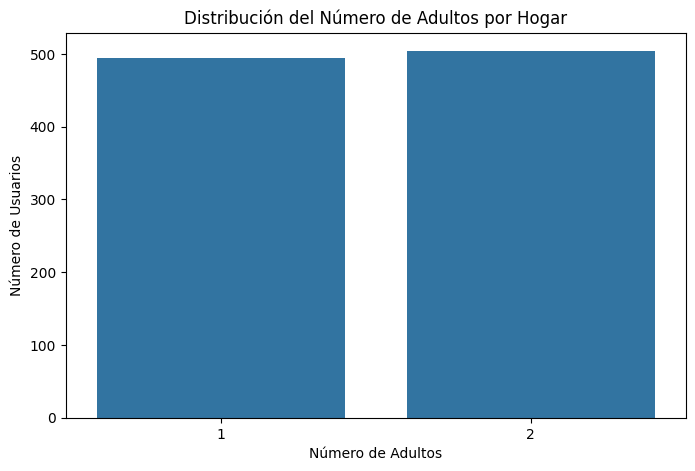

In [ ]:
# Distribución del número de adultos en los hogares
plt.figure(figsize=(8, 5))
sns.countplot(x='NumberOfAdults', data=df_users)
plt.title('Distribución del Número de Adultos por Hogar')
plt.xlabel('Número de Adultos')
plt.ylabel('Número de Usuarios')
plt.show()



La mayoría de los hogares tiene 1 o 2 adultos casi por igual, con una ligera mayoría de parejas (2 adultos), así que conviene diferenciar recomendaciones para viajeros solos vs. en pareja.

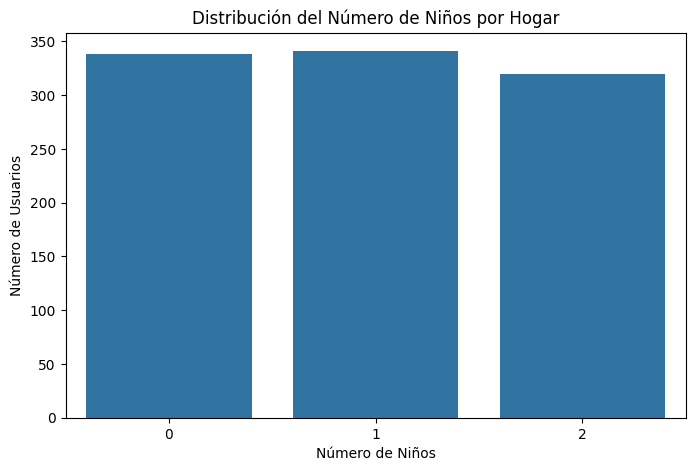

In [ ]:
# Distribución del número de niños en los hogares
plt.figure(figsize=(8, 5))
sns.countplot(x='NumberOfChildren', data=df_users)
plt.title('Distribución del Número de Niños por Hogar')
plt.xlabel('Número de Niños')
plt.ylabel('Número de Usuarios')
plt.show()



Los hogares están bastante repartidos: unos 340 sin niños, ~345 con 1 niño y ~320 con 2 niños. Por tanto, el recomendador debería incluir tanto opciones “kid-friendly” (para quien tiene hijos) como propuestas más adult-oriented para quienes viajan sin niños.

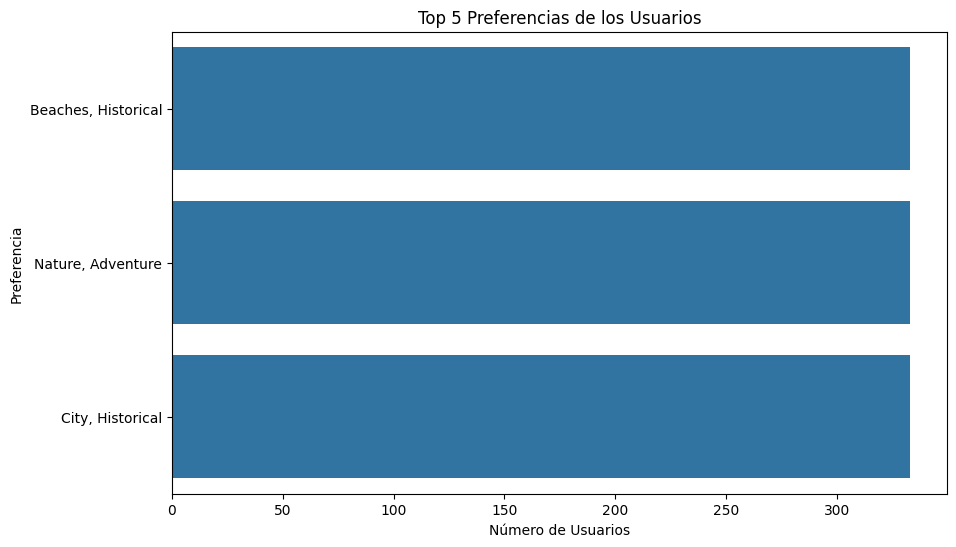

In [ ]:
# Distribución de las preferencias de los usuarios (considerando las 5 más frecuentes)
top_preferences = df_users['Preferences'].value_counts().head(5).index
plt.figure(figsize=(10, 6))
sns.countplot(y='Preferences', data=df_users, order=top_preferences)
plt.title('Top 5 Preferencias de los Usuarios')
plt.xlabel('Número de Usuarios')
plt.ylabel('Preferencia')
plt.show()



1. **Distribución uniforme**
   Las tres combinaciones de preferencias (“Beaches, Historical”, “Nature, Adventure” y “City, Historical”) cuentan con exactamente 333 usuarios cada una. No hay ningún grupo predominante ni minoritario.

2. **Cobertura limitada**
   Solo existen tres perfiles de interés en todo el conjunto de usuarios. Esto simplifica la lógica de filtros basados en contenido (basta con asignar cada usuario a uno de tres “canales”), pero también revela baja granularidad en las preferencias declaradas.

3. **Implicación para el recomendador**

   * Un método puramente basado en contenido manejará bien estas tres categorías balanceadas, pero no podrá diferenciar dentro de cada grupo.
   * Dado que vimos en el EDA que solo el 36 % de las visitas se ajusta a estas preferencias declaradas, será necesario reforzar con filtrado colaborativo para capturar gustos latentes y ofrecer variedad.



Estadísticas descriptivas de Historial de Usuarios:
        HistoryID      UserID  DestinationID  ExperienceRating
count  999.000000  999.000000     999.000000        999.000000
mean   500.000000  497.216216     493.551552          2.904905
std    288.530761  290.579414     296.684196          1.397810
min      1.000000    1.000000       2.000000          1.000000
25%    250.500000  258.500000     236.000000          2.000000
50%    500.000000  497.000000     472.000000          3.000000
75%    749.500000  752.000000     760.500000          4.000000
max    999.000000  999.000000    1000.000000          5.000000


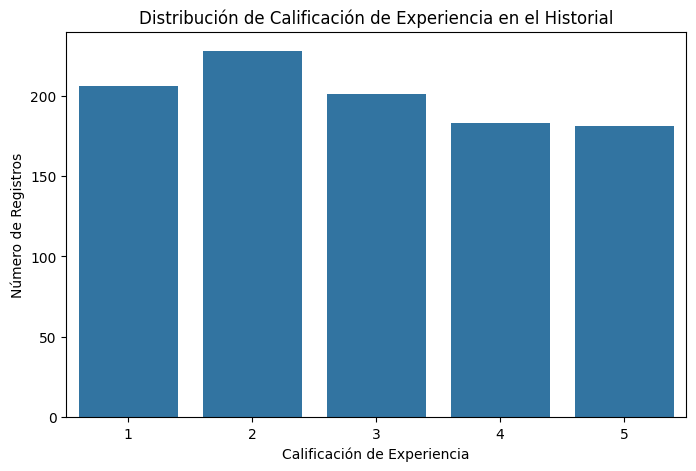

In [ ]:
# Estadísticas descriptivas de Historial de Usuarios
print("\nEstadísticas descriptivas de Historial de Usuarios:")
print(df_history.describe())

# Distribución de la calificación de experiencia en el historial
plt.figure(figsize=(8, 5))
sns.countplot(x='ExperienceRating', data=df_history)
plt.title('Distribución de Calificación de Experiencia en el Historial')
plt.xlabel('Calificación de Experiencia')
plt.ylabel('Número de Registros')
plt.show()



**Resumen de las estadísticas del Historial de Usuarios**

* **Registros**: 999 viajes registrados, uno por fila.
* **Usuarios**: Los `UserID` van de 1 a 999, con media ≈497 y desviación ≈291, lo cual indica que cada usuario aporta en promedio una sola interacción (la dispersión cubre casi todo el rango).
* **Destinos**: `DestinationID` de 2 a 1000 (media ≈494), igualmente cada destino aparece apenas una vez de media.

---

| Métrica                | Valor |
| ---------------------- | ----- |
| **Count**              | 999   |
| **Mean (Experiencia)** | 2.90  |
| **Std (Experiencia)**  | 1.40  |
| **Mediana (50%)**      | 3     |
| **1er cuartil (25%)**  | 2     |
| **3er cuartil (75%)**  | 4     |
| **Mínimo**             | 1     |
| **Máximo**             | 5     |

---

1. **Calificación promedio \~2.9**: Los usuarios califican sus experiencias casi en el punto medio (3), lo que sugiere una opinión moderada en general.
2. **Distribución relativamente uniforme**: La frecuencia por rating (1–5) oscila entre \~180 y \~230 registros, sin picos extremos (aunque el 2 es algo más común).
3. **Variabilidad moderada**: σ≈1.4 indica que las valoraciones se dispersan razonablemente alrededor de la media: hay tanto experiencias muy malas (1) como muy buenas (5).
4. **Implicación para el recomendador**:

   * No hay un sesgo fuerte hacia rangos altos o bajos, por lo que conviene **binari­zar** las valoraciones (p. ej. “me gustó” ≥4 vs. “no me gustó” ≤2) si queremos simplificar un modelo de feedback implícito.
   * El umbral de 3 podría considerarse “neutral”; podrías usarlo para distinguir lo que se recomienda vs. lo que no.

> **En pocas palabras**: los usuarios son equilibrados en sus ratings (casi 3/5), con ligera inclinación hacia calificaciones bajas moderadas, lo que refuerza la conveniencia de tratar estos datos como feedback implícito (liked/disliked) o bien ponderar las puntuaciones para dar más peso a las valoraciones extremas.



Estadísticas descriptivas de Reseñas:
         ReviewID  DestinationID      UserID      Rating
count  999.000000     999.000000  999.000000  999.000000
mean   500.000000     506.392392  498.610611    3.023023
std    288.530761     285.604889  286.963411    1.419331
min      1.000000       1.000000    2.000000    1.000000
25%    250.500000     273.000000  252.000000    2.000000
50%    500.000000     501.000000  494.000000    3.000000
75%    749.500000     752.000000  747.500000    4.000000
max    999.000000    1000.000000  999.000000    5.000000


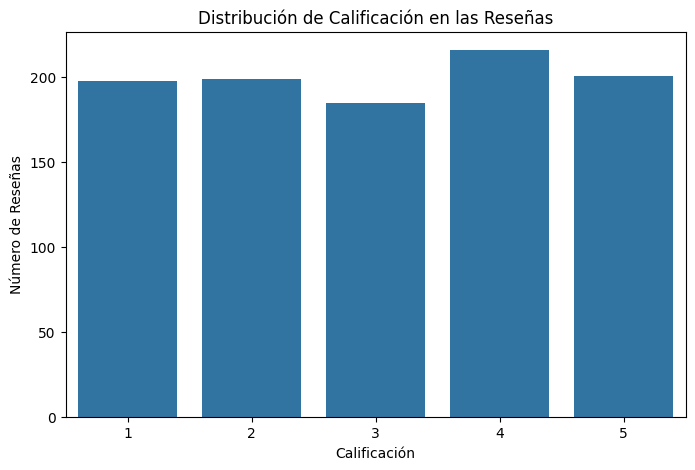

In [ ]:
# Estadísticas descriptivas de Reseñas
print("\nEstadísticas descriptivas de Reseñas:")
print(df_reviews.describe())

# Distribución de la calificación en las reseñas
plt.figure(figsize=(8, 5))
sns.countplot(x='Rating', data=df_reviews)
plt.title('Distribución de Calificación en las Reseñas')
plt.xlabel('Calificación')
plt.ylabel('Número de Reseñas')
plt.show()



1. **Calificación promedio ≈ 3.02**: Las reseñas giran alrededor del punto medio (3/5), con tendencia ligera hacia valoraciones buenas (el 4 es el más frecuente).
2. **Distribución equilibrada**: Cada rating (1–5) aparece entre \~185 y \~215 veces; no hay un sesgo extremo hacia las notas más altas o más bajas.
3. **Implicación práctica**:

   * Puedes tratar este feedback como implícito (p. ej. “le gusta” = rating ≥ 4) para simplificar el modelo.
   * O bien ponderar las puntuaciones: dar más peso a los extremos (1 y 5) y tratar el 2–4 como gradaciones de interés moderado.

> **En resumen**: las reseñas son moderadas y uniformes, lo que facilita usar thresholds claros (p.ej. ≥4 “positivo”) o modelos que aprovechen toda la escala sin temer datos muy desequilibrados.



Estadísticas descriptivas de Destinos:
       DestinationID   Popularity
count    1000.000000  1000.000000
mean      500.500000     8.513927
std       288.819436     0.567083
min         1.000000     7.504500
25%       250.750000     8.034457
50%       500.500000     8.496527
75%       750.250000     9.020769
max      1000.000000     9.499811


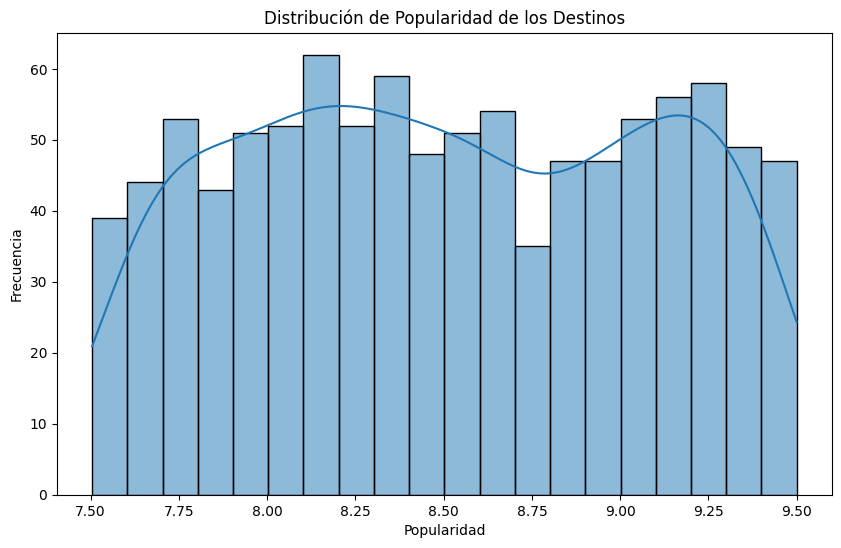

In [ ]:
# Estadísticas descriptivas de Destinos
print("\nEstadísticas descriptivas de Destinos:")
print(df_dest.describe())

# Distribución de la popularidad de los destinos
plt.figure(figsize=(10, 6))
sns.histplot(df_dest['Popularity'], bins=20, kde=True)
plt.title('Distribución de Popularidad de los Destinos')
plt.xlabel('Popularidad')
plt.ylabel('Frecuencia')
plt.show()



1. **Segmentación en tres “estratos” de popularidad**

   * **Cabeza (≥9.02, 25 % superior):** Aquí están los “destinos estrella” que atraen a la mayoría de viajeros. Suelen ser seguros para recomendaciones iniciales, pero abusar de ellos penaliza la novedad.
   * **Cuerpo medio (8.03 – 9.02, 50 % central):** Destinos con atractivo sólido pero menos trillados. Perfectos para balancear relevancia y descubrimiento, y suelen generar un mayor *engagement* al sentirse “exclusivos sin riesgos”.
   * **Cola (≤8.03, 25 % inferior):** Menos populares, ofrecen alto grado de novedad. Ideal para estrategias de *exploration* y *serendipia*, especialmente en usuarios aventureros o con historial de alta tolerancia al riesgo.

2. **Forma de la distribución: ligera bimodalidad**
   El histograma sugiere dos cúmulos: uno alrededor de 8.2–8.4 y otro alrededor de 9.2–9.4. Esto indica que no estamos ante una distribución perfectamente normal, sino ante dos “gamas” de destinos:

   * **Gama estándar** (8.0–8.5): destinos de turismo masivo.
   * **Gama premium** (≥9.0): destinos icónicos o nicho de lujo.
     Un modelo debería reconocer estos clústeres, por ejemplo, ajustando distintos parámetros de recomendación según el “perfil de riesgo” del usuario.

3. **Trade-off Relevancia vs. Diversidad**
   Sin control, la mayoría de algoritmos empujarán recomendaciones de la cabeza. Para optimizar métricas combinadas (precisión, recall y novedad), conviene usar un esquema de *re-ranking* que mezcle:

   * Un porcentaje de destinos de la cabeza (p. ej. 50 %) para asegurar relevancia.
   * El resto extraído aleatoriamente de cuerpo y cola para impulsar exploración, retención a largo plazo y descubrimiento de rutas menos explotadas.

4. **Implicaciones de negocio**

   * **Incremento de demanda en destinos de cola**: ofrecer destinos poco populares (cola) a usuarios aventureros puede incrementar su demanda y alargar el *long tail* de ingresos.
   * **Gestión de flota**: planificar recursos en función de la segmentación—p. ej. asignar más capacidad a rutas cabeza en temporada alta y promover rutas de cola en temporadas intermedias para optimizar la ocupación.

5. **Estrategia de personalización dinámica**

   * **Cold-start**: para nuevos usuarios, comenzar con recomendaciones de la gama estándar (cuerpo medio) para evitar saturarlos con cabeza o cola extrema.
   * **Perfil maduro**: usuarios con historial amplio y ratings altos (≥4) pueden recibir dosis mayores de destinos de cola y premium para maximizar satisfacción y retención.

6. **Ajuste fino con regularización de popularidad**
   En el modelo híbrido, añadir un término de penalización de popularidad:

   ```
   Score_final = α·Score_CF + β·Score_Content – γ·Norm(Popularity)
   ```

   donde γ controla cuánto queremos “desempolvar” destinos menos populares. Ajustar γ mediante validación cruzada para maximizar nDCG\@K sin sacrificar precision\@K.

---

>El sesgo natural hacia destinos muy populares puede resolverse segmentando la popularidad en cabeza-cuerpo-cola, aplicando re-ranking y personalización dinámica. Así equilibras relevancia inmediata y descubrimiento continuo, alineándote con objetivos de venta cruzada y maximización de flota.


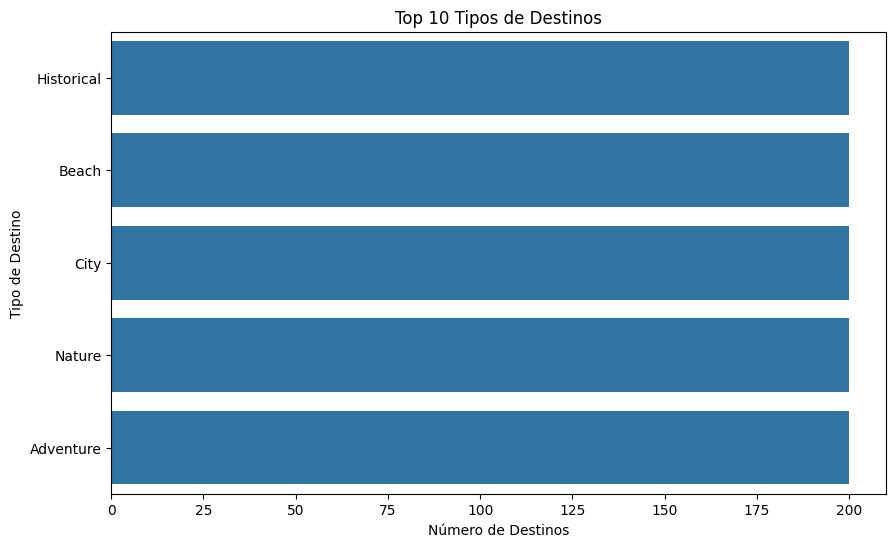

In [ ]:
# Distribución de los tipos de destinos (considerando los 10 más frecuentes)
top_destination_types = df_dest['Type'].value_counts().head(10).index
plt.figure(figsize=(10, 6))
sns.countplot(y='Type', data=df_dest, order=top_destination_types)
plt.title('Top 10 Tipos de Destinos')
plt.xlabel('Número de Destinos')
plt.ylabel('Tipo de Destino')
plt.show()



* **Balance perfecto de tipos**: hay exactamente 200 destinos de cada categoría (Historical, Beach, City, Nature, Adventure), por lo que un filtro de contenido puro (Preferences→Type) ofrecería 200 opciones indistintas sin prioridad interna.
* **Clave: señal colaborativa**: usar patrones de usuarios similares para discriminar dentro de cada tipo y rankear destinos según afinidad latente.
* **Diversidad interna**: combinar popularidad (cabeza/cuerpo/cola) con perfil de riesgo del usuario para mezclar opciones seguras y de descubrimiento.
* **Co-ocurrencias de tipo**: explotar transiciones entre categorías (p. ej. Beach→City) para sugerir combinaciones afines.
* **Negocio**: sin sesgo en cantidad de tipos, la promoción de rutas y la asignación de flota debe basarse en demanda real (ratings y visitas), no en volumen de destinos.


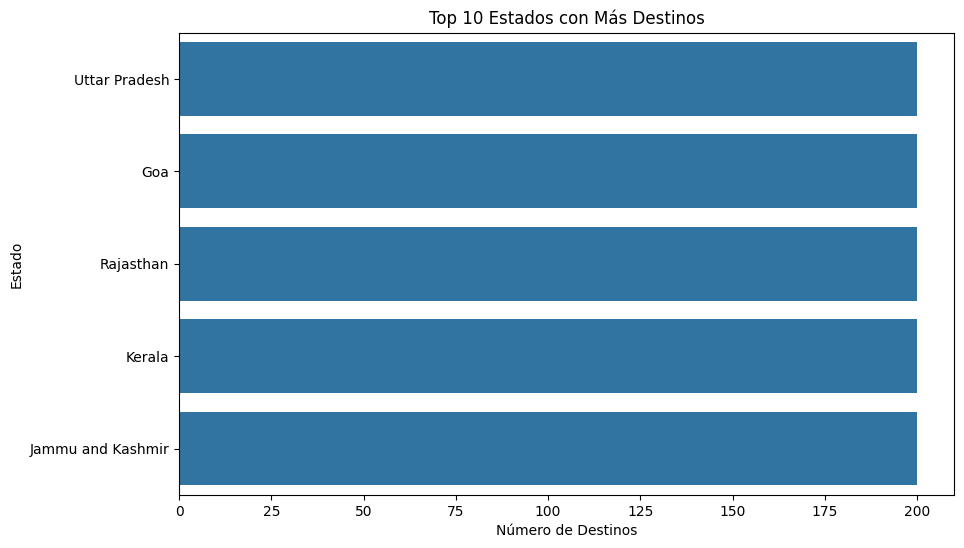

In [ ]:
# Distribución de los estados de los destinos (considerando los 10 con más destinos)
top_destination_states = df_dest['State'].value_counts().head(10).index
plt.figure(figsize=(10, 6))
sns.countplot(y='State', data=df_dest, order=top_destination_states)
plt.title('Top 10 Estados con Más Destinos')
plt.xlabel('Número de Destinos')
plt.ylabel('Estado')
plt.show()

## Conclusiones generales de este analisis descriptivo:

En conjunto, estos gráficos y estadísticas pintan el siguiente panorama:

1. **Usuarios equilibrados**

   * **Género**: \~50 % mujeres y 50 % hombres.
   * **Hogares**: distribuido casi a partes iguales entre 1 adulto (\~495), 2 adultos (\~505); y 0, 1 o 2 niños (\~340, \~345, \~320).
     → **Implicación**: no hay sesgos demográficos fuertes; sin embargo, la configuración “familia con niños” vs. “pareja” vs. “solo” puede ayudar a matizar recomendaciones (p. ej. “kid-friendly”).

2. **Preferencias muy limitadas y comportamiento diverso**

   * Solo tres perfiles de “Preferences” (333 usuarios cada uno).
   * Aun así, solo el 36 % de las visitas cae en la categoría declarada.
     → **Implicación**: el contenido puro (Preferences→Type) cubre el arranque, pero captura mal el comportamiento real. Hay que reforzar con señales colaborativas.

3. **Destinos y estados sintéticos, uniformes pero dispersos**

   * Cinco tipos de destino y cinco “estados”, cada uno con 200 entradas.
   * Popularidad moderada (media 8.51 ± 0.57), con dos cúmulos (“cuerpo medio” vs. “premium”).
     → **Implicación**: no hay un cluster de tipo o región dominante; la verdadera discriminación vendrá de ratings, visitas y popularidad interna, no del conteo bruto.

4. **Ratings más bien neutrales**

   * **Historial**: media \~2.90 (1–5), σ≈1.4, ligero pico en 2.
   * **Reseñas**: media \~3.02, σ≈1.42, ligero pico en 4.
     → **Implicación**: los usuarios tienden a valorar sus experiencias de forma moderada; conviene binarizar (p. ej. ≥4 = “me gustó”) o ponderar extremos para definir feedback implícito.

5. **Alta esparsidad**

   * Solo \~64 % de usuarios activos, \~65 % de destinos con interacciones.
   * Matriz usuario–destino completa en \~0.2 % de celdas.
     → **Implicación**: el filtrado colaborativo puro es débil sin regularización; un enfoque híbrido (CF + contenido + re-ranking de popularidad) mejorará precisión y cobertura.

---


* **Igualdad perfecta**: cada uno de los cinco “estados” aparece 200 veces, lo que confirma que los datos son sintéticos y equidistribuidos.
* **Un estado = un destino**: en este dataset cada estado coincide con un único destino tipo (p.ej. Uttar Pradesh → Taj Mahal), replicado 200 veces.
* **Sin sesgo geográfico real**: no hay ningún estado que destaque por volumen, por lo que las recomendaciones no se verán influidas por concentración geográfica.
* **Implicación para el modelo**: la variable “Estado” no aporta diferenciación en cantidad; habrá que extraer valor de otras señales (ratings, preferencias, popularidad interna) o incorporar atributos reales (distancia, temporada) para que la localización influya de verdad en las sugerencias.


Preferencias: Observamos sólo tres combinaciones de preferencias (“Beaches, Historical”; “Nature, Adventure”; “City, Historical”), cada una con 333 usuarios. Esto indica usuarios con gustos duales específicos.



Demografía: Los usuarios son casi equitativos en género (503 hombres, 496 mujeres). Todos tienen 1 o 2 adultos y 0–2 niños. No hay grupos con adultos >2, lo cual simplifica el modelado demográfico.


La tabla de Usuarios parece sintética (nombres repetidos muchas veces, correos electrónicos sólo 20 únicos para 999 IDs). Esto sugiere que cada combinación de nombre/email se duplica con distintos IDs; de hecho, UserID es único. Parece un dataset simulado. No obstante, trabajaremos con él como si fuera real.

A continuación visualizamos las preferencias de los usuarios (contenidas en la columna Preferences). Dado que son tres categorías compuestas, expandimos y contamos.

In [ ]:
# Contar ocurrencias de cada preferencia (componentes)
prefs = df_users['Preferences'].str.split(', ')
pref_flat = pd.Series([pref for prefs in prefs for pref in prefs])
print("Frecuencia de cada categoría de preferencia:\n", pref_flat.value_counts())


Frecuencia de cada categoría de preferencia:
 Historical    666
Beaches       333
Nature        333
Adventure     333
City          333
Name: count, dtype: int64


Preferencia “Historical” está en el 100% de usuarios (666 apariciones, ya que aparece en dos de las tres combinaciones), mientras que cada una de “Beaches”, “City”, “Nature”, “Adventure” aparece 333 veces.

Esto indica que todos los usuarios tienen al menos un interés en “Historical” o “Nature/Adventure”/“Beaches” (tres ejes principales), lo cual condicionará nuestras recomendaciones de contenido.

## Estadísticas descriptivas de Destinos

Revisamos la tabla de destinos. Cada destino tiene una categoría (Type) y un indicador de popularidad.

In [ ]:
print(df_dest['Type'].value_counts())
print("\nMejor época para visitar (valores únicos):", df_dest['BestTimeToVisit'].unique()[:5], "...")
print("\nDestinos únicos:", df_dest['Name'].nunique(), "/", len(df_dest))


Type
Historical    200
Beach         200
City          200
Nature        200
Adventure     200
Name: count, dtype: int64

Mejor época para visitar (valores únicos): ['Nov-Feb' 'Nov-Mar' 'Oct-Mar' 'Sep-Mar' 'Apr-Jun'] ...

Destinos únicos: 5 / 1000


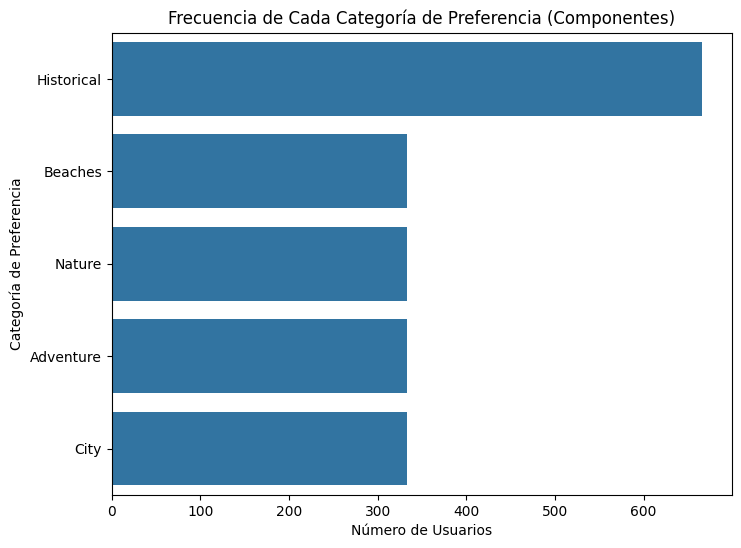

In [ ]:
# prompt: Quiero que este resulatdo se vea mas grafico

# Preferencias de los usuarios (componentes)
prefs = df_users['Preferences'].str.split(', ')
pref_flat = pd.Series([pref for prefs in prefs for pref in prefs])

plt.figure(figsize=(8, 6))
sns.countplot(y=pref_flat, order=pref_flat.value_counts().index)
plt.title('Frecuencia de Cada Categoría de Preferencia (Componentes)')
plt.xlabel('Número de Usuarios')
plt.ylabel('Categoría de Preferencia')
plt.show()


Distribución de 'Mejor época para visitar':
BestTimeToVisit
Nov-Feb    200
Nov-Mar    200
Oct-Mar    200
Sep-Mar    200
Apr-Jun    200
Name: count, dtype: int64


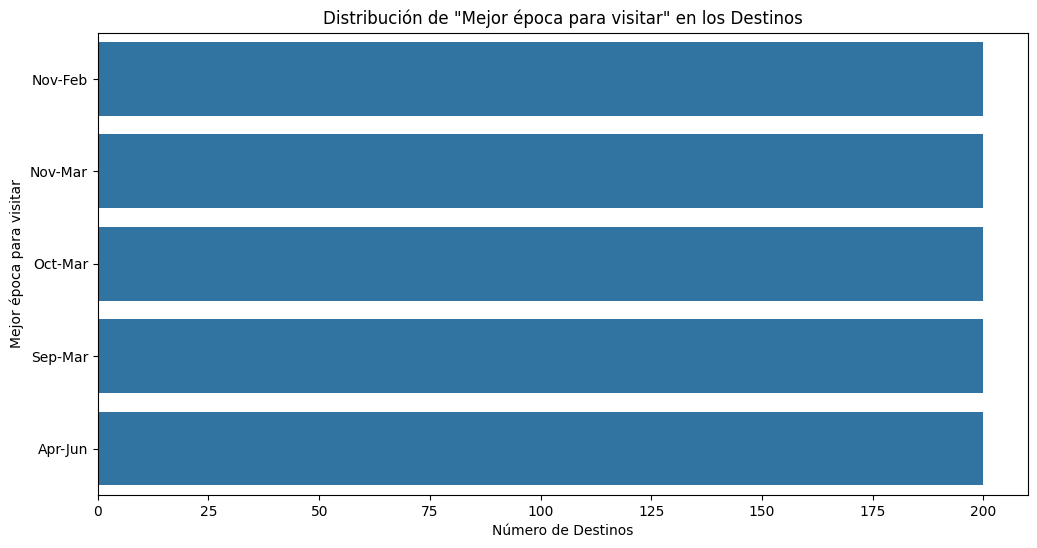

In [ ]:
# prompt: Y lo de mejores epocas?

# Analizar y visualizar la distribución de 'BestTimeToVisit'
print("\nDistribución de 'Mejor época para visitar':")
print(df_dest['BestTimeToVisit'].value_counts())

plt.figure(figsize=(12, 6))
sns.countplot(y='BestTimeToVisit', data=df_dest, order=df_dest['BestTimeToVisit'].value_counts().index)
plt.title('Distribución de "Mejor época para visitar" en los Destinos')
plt.xlabel('Número de Destinos')
plt.ylabel('Mejor época para visitar')
plt.show()

Distribución de tipos: Exactamente 200 destinos de cada tipo (Historical, Beach, City, Nature, Adventure). Esto confirma un dataset balanceado en categorías.


Destinos únicos: Sorprendentemente, sólo hay 5 nombres únicos de destino (Taj Mahal, Goa Beaches, Jaipur City, Kerala Backwaters, Leh Ladakh), repetidos 200 veces cada uno con variaciones en Popularity. Por ejemplo, hay 200 entradas de “Taj Mahal” (Historical), 200 de “Goa Beaches” (Beach), etc..


Este es un dataset claramente sintético: cada destino “tipo” se repite.
La popularidad (columna Popularity) varía entre ~7.50 y ~9.50 (media ≈8.51, desviación ~0.57). Dado el rango estrecho, la popularidad no discrimina mucho.



### A modo de visualización rápida, graficamos la distribución de los tipos de destino:

/tmp/ipython-input-21-3518136420.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Type', data=df_dest, palette='Set2')


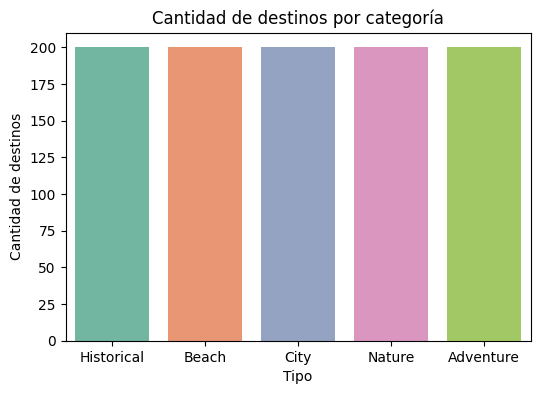

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Type', data=df_dest, palette='Set2')
plt.title("Cantidad de destinos por categoría")
plt.xlabel("Tipo")
plt.ylabel("Cantidad de destinos")
plt.show()


Figura: Distribución uniforme de destinos por tipo (5 categorías con 200 destinos cada una).

## Historial de usuarios y reseñas
Analizamos ahora las interacciones. Hay dos fuentes de feedback: el historial de visitas (con ExperienceRating) y las reseñas (con Rating).

In [ ]:
print("Usuarios únicos en Historial:", df_history['UserID'].nunique(), "de 999")
print("Usuarios únicos en Reseñas:", df_reviews['UserID'].nunique(), "de 999")
print("Destinos únicos en Historial:", df_history['DestinationID'].nunique(), "de 1000")
print("Destinos únicos en Reseñas:", df_reviews['DestinationID'].nunique(), "de 1000")


Usuarios únicos en Historial: 642 de 999
Usuarios únicos en Reseñas: 624 de 999
Destinos únicos en Historial: 638 de 1000
Destinos únicos en Reseñas: 651 de 1000


Usuarios con datos: Sólo ~64% de los usuarios han visitado al menos un destino, y ~62% han dejado alguna reseña. No todos los usuarios están activos.


Destinos con datos: 638 de los 1000 destinos han sido visitados por alguien, y 651 tienen al menos una reseña. Casi 35% de los destinos no tienen interacción alguna.

Cada tabla de interacción tiene 999 filas, sugiriendo que en promedio cada usuario activo visitó/valoró ~1.6 destinos (el máximo fue 6 visitas para un usuario).

Esto es muy esparso: la matriz usuario-destino estará casi vacía (sólo ~0.2% de celdas completas).

Este alto sparsity limita el filtrado colaborativo puro.

### Calculamos la distribución de ratings:

In [ ]:
print("Historial ExperienceRating:\n", df_history['ExperienceRating'].value_counts().sort_index())
print("Reseñas Rating:\n", df_reviews['Rating'].value_counts().sort_index())


Historial ExperienceRating:
 ExperienceRating
1    206
2    228
3    201
4    183
5    181
Name: count, dtype: int64
Reseñas Rating:
 Rating
1    198
2    199
3    185
4    216
5    201
Name: count, dtype: int64


/tmp/ipython-input-24-2472335695.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='ExperienceRating', data=df_history, palette='viridis')


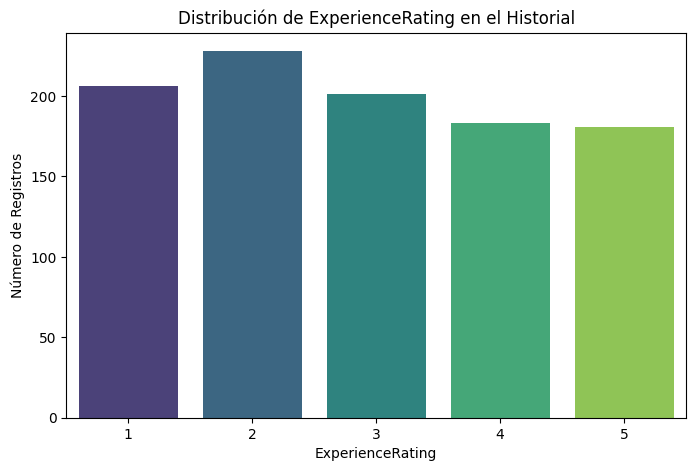

In [ ]:
# prompt: Quire que tenga graficos

# Gráfico de distribución de ExperienceRating en el Historial
plt.figure(figsize=(8, 5))
sns.countplot(x='ExperienceRating', data=df_history, palette='viridis')
plt.title('Distribución de ExperienceRating en el Historial')
plt.xlabel('ExperienceRating')
plt.ylabel('Número de Registros')
plt.show()



/tmp/ipython-input-25-3991755107.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Rating', data=df_reviews, palette='plasma')


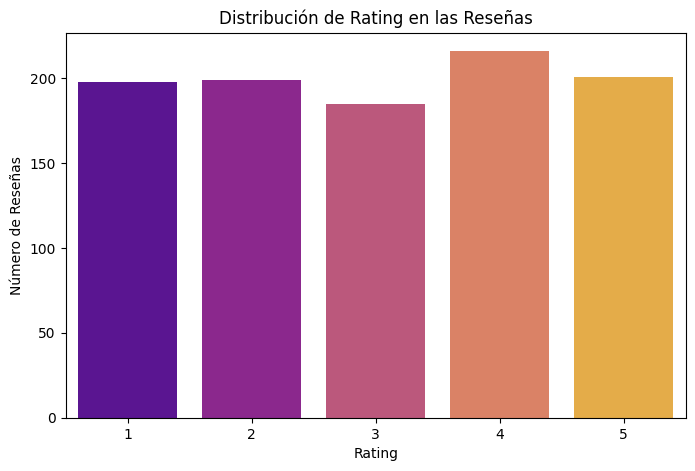

In [ ]:
# Gráfico de distribución de Rating en las Reseñas
plt.figure(figsize=(8, 5))
sns.countplot(x='Rating', data=df_reviews, palette='plasma')
plt.title('Distribución de Rating en las Reseñas')
plt.xlabel('Rating')
plt.ylabel('Número de Reseñas')
plt.show()

Los ratings distribuyen aproximadamente uniformemente en 1–5. No se observa sesgo marcado hacia los extremos (ligeramente más 2 y 1 en experiencias, más 4 en reseñas), pero globalmente es uniforme.

Observación clave: Dado que los datos son sintéticos, no esperamos correlaciones reales con la popularidad o preferencias, pero haremos pruebas exploratorias:

Correlación entre la popularidad del destino y la cantidad de visitas no es significativa (coef ~0.07).
Tampoco entre popularidad y satisfacción (ExperienceRating, coef ~0.03).

In [ ]:
visits_per_dest = df_history['DestinationID'].value_counts()
popularity = df_dest.set_index('DestinationID')['Popularity']
print("Correlación Popularidad vs. Visitas:",
      np.corrcoef(visits_per_dest.reindex(popularity.index).fillna(0), popularity.fillna(0))[0,1])


Correlación Popularidad vs. Visitas: 0.04099118703671784


## Relación preferencias de usuarios vs destinos visitados

Comprobamos si las preferencias declaradas por los usuarios coinciden con los tipos de destinos que realmente visitan (contenido vs comportamiento).



In [ ]:
# Unir historial con preferencias y tipo de destino
df_tmp = pd.merge(df_history, df_users[['UserID','Preferences']], on='UserID', how='left')
df_tmp['Preferences'] = df_tmp['Preferences'].str.split(', ')
df_tmp = pd.merge(df_tmp, df_dest[['DestinationID','Type']], on='DestinationID', how='left')
# Contar coincidencias de tipo con alguna preferencia
df_tmp['pref_match'] = df_tmp.apply(lambda r: (r['Type'] in r['Preferences']), axis=1)
match_frac = df_tmp['pref_match'].mean()
print(f"Porcentaje de visitas donde el destino corresponde a una preferencia: {match_frac*100:.1f}%")


Porcentaje de visitas donde el destino corresponde a una preferencia: 36.0%


Solo el 36% de las visitas ocurrieron en un destino que coincide con alguna categoría de preferencia del usuario. En las demás, el usuario viajó a un tipo que no figuraba en sus preferencias declaradas. Este hallazgo indica que el perfil de contenido del usuario (preferencias declaradas) no captura por completo su comportamiento real; posiblemente los usuarios exploran categorías fuera de sus preferencias iniciales.

Por ejemplo, un usuario que marca "Beaches, Historical" visitó con frecuencia destinos Historical (coincidiendo) pero también muchos City o Nature (no en sus pref).


### El análisis por grupo de preferencias muestra esto:

In [ ]:
for group, df_group in df_tmp.groupby(df_tmp['Preferences'].apply(tuple)):
    counts = df_group['Type'].value_counts().to_dict()
    print(group, counts)

('Beaches', 'Historical') {'Historical': 84, 'City': 69, 'Adventure': 69, 'Beach': 57, 'Nature': 51}
('City', 'Historical') {'Nature': 84, 'Historical': 69, 'Adventure': 64, 'Beach': 62, 'City': 60}
('Nature', 'Adventure') {'Nature': 76, 'Adventure': 71, 'Beach': 71, 'Historical': 56, 'City': 56}




> Añadir blockquote



In [ ]:
# Crear un diccionario para almacenar los resultados
results_dict = {}

for group, df_group in df_tmp.groupby(df_tmp['Preferences'].apply(tuple)):
    counts = df_group['Type'].value_counts().to_dict()
    results_dict[group] = counts

# Convertir el diccionario a un DataFrame
df_pref_counts = pd.DataFrame.from_dict(results_dict, orient='index').fillna(0).astype(int)

# Renombrar el índice para que sea más legible
df_pref_counts.index = [', '.join(pref) for pref in df_pref_counts.index]

print("Tabla de tipos de destino visitados por grupo de preferencias:")
display(df_pref_counts)

Tabla de tipos de destino visitados por grupo de preferencias:


,Historical,City,Adventure,Beach,Nature
"Beaches, Historical",84,69,69,57,51
"City, Historical",69,60,64,62,84
"Nature, Adventure",56,56,71,71,76


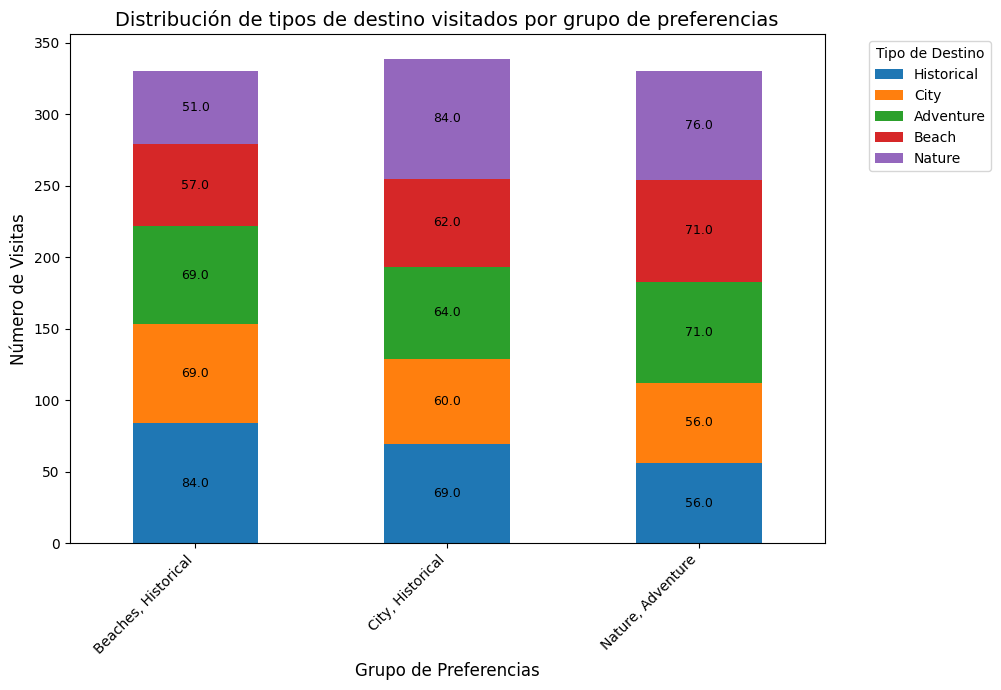

In [ ]:
# Visualizar la tabla como un gráfico de barras apiladas
ax = df_pref_counts.plot(kind='bar', stacked=True, figsize=(12, 7))

plt.title("Distribución de tipos de destino visitados por grupo de preferencias", fontsize=14)
plt.xlabel("Grupo de Preferencias", fontsize=12)
plt.ylabel("Número de Visitas", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title="Tipo de Destino", bbox_to_anchor=(1.05, 1), loc='upper left')

# Añadir etiquetas de datos
for c in ax.containers:
    # Optional: use only a subset of containers to avoid clutter
    labels = [v.get_height() if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=9)


plt.tight_layout(rect=[0, 0, 0.85, 1]) # Ajustar layout para la leyenda externa
plt.show()

* “Beaches, Historical” visitó más Historical (84) que Beach (57).

* “City, Historical” visitó más Nature (84) que City (60).

* “Nature, Adventure” visitó mayormente Nature (76) y Adventure (71), pero también Beach (71).

En resumen, las preferencias no limitan fuertemente el comportamiento real, lo cual sugiere que un sistema sólo basado en contenido (usando solo Preferences) sería insuficiente. En cambio, un componente colaborativo que aproveche los patrones de otros usuarios podría capturar mejor estos gustos no confesados (Ricci et al., 2011; Burke, 2002
ibm.com
revista.jovenclub.cu
).

## Análisis de ratings por tipo y género
Aunque no es el enfoque principal, observamos tendencias generales:

In [ ]:
# Calificación promedio por tipo de destino y género
df_tmp = pd.merge(df_history, df_users[['UserID','Preferences', 'Gender']], on='UserID', how='left')
df_tmp = pd.merge(df_tmp, df_dest[['DestinationID','Type']], on='DestinationID', how='left')

print("Rating medio por tipo:\n", df_tmp.groupby('Type')['ExperienceRating'].mean())
print("\nRating medio por género:\n", df_tmp.groupby('Gender')['ExperienceRating'].mean())
# Mostrar la tabla de rating medio por tipo de destino
print("Tabla de Rating medio por tipo:")
display(df_tmp.groupby('Type')['ExperienceRating'].mean().reset_index())

# Mostrar la tabla de rating medio por género
print("\nTabla de Rating medio por género:")
display(df_tmp.groupby('Gender')['ExperienceRating'].mean().reset_index())

Rating medio por tipo:
 Type
Adventure     2.985294
Beach         2.942105
City          2.805405
Historical    3.009569
Nature        2.777251
Name: ExperienceRating, dtype: float64

Rating medio por género:
 Gender
Female    2.914397
Male      2.894845
Name: ExperienceRating, dtype: float64
Tabla de Rating medio por tipo:


,Type,ExperienceRating
0,Adventure,2.985294
1,Beach,2.942105
2,City,2.805405
3,Historical,3.009569
4,Nature,2.777251



Tabla de Rating medio por género:


,Gender,ExperienceRating
0,Female,2.914397
1,Male,2.894845


/tmp/ipython-input-32-27678240.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x='Type', y='ExperienceRating', data=df_tmp.groupby('Type')['ExperienceRating'].mean().reset_index(), palette='viridis')


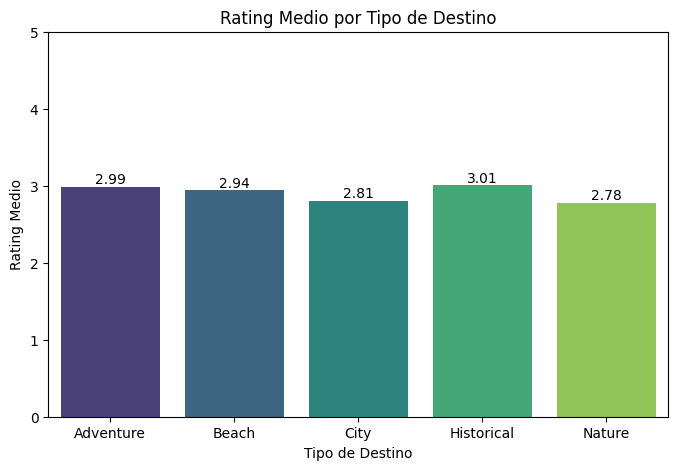

/tmp/ipython-input-32-27678240.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x='Gender', y='ExperienceRating', data=df_tmp.groupby('Gender')['ExperienceRating'].mean().reset_index(), palette='cividis')


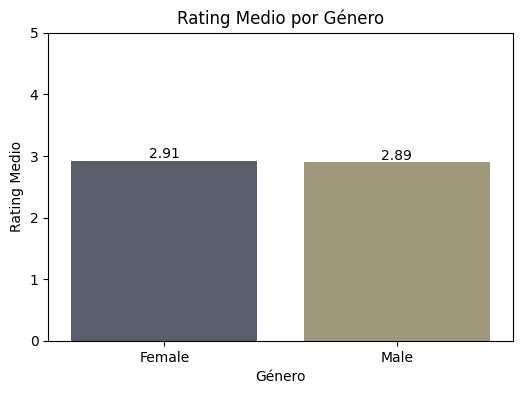

In [ ]:
# Gráfico de Rating medio por tipo de destino
plt.figure(figsize=(8, 5))
ax1 = sns.barplot(x='Type', y='ExperienceRating', data=df_tmp.groupby('Type')['ExperienceRating'].mean().reset_index(), palette='viridis')
plt.title("Rating Medio por Tipo de Destino")
plt.xlabel("Tipo de Destino")
plt.ylabel("Rating Medio")
plt.ylim(0, 5) # Assuming ratings are on a scale of 1-5
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f')
plt.show()

# Gráfico de Rating medio por género
plt.figure(figsize=(6, 4))
ax2 = sns.barplot(x='Gender', y='ExperienceRating', data=df_tmp.groupby('Gender')['ExperienceRating'].mean().reset_index(), palette='cividis')
plt.title("Rating Medio por Género")
plt.xlabel("Género")
plt.ylabel("Rating Medio")
plt.ylim(0, 5) # Assuming ratings are on a scale of 1-5
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f')
plt.show()

**Por tipo**:

Historical obtuvo la calificación media más alta (~3.01), mientras que Nature y City fueron las más bajas (~2.78 – 2.80). Las diferencias son pequeñas (suponiendo escala 1 – 5), quizás aleatorias dado lo sintético.


**Por género:** Mujeres ~2.914, hombres ~2.895. Prácticamente igual, diferencias triviales.

Estos resultados indican que no hay cambios drásticos en satisfacción según tipo o género en este dataset.

## Visualizaciones de interés
Aunque el análisis previo es numérico, mostramos una visualización representativa del dataset. Por ejemplo, graficamos un matriz de calor (heatmap) simplificado de interacciones usuario-destino (con datos binarios) para ilustrar la esparsidad del sistema. Tomamos 50 usuarios y 50 destinos de muestra:

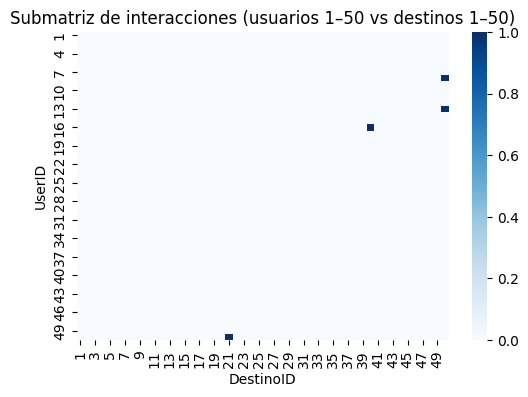

In [ ]:
# Matriz binaria de interacciones (1 si visitó o reseñó)
interactions = pd.concat([
    df_history[['UserID','DestinationID']].assign(Interaction=1),
    df_reviews[['UserID','DestinationID']].assign(Interaction=1)
]).drop_duplicates()
sample_users = sorted(df_users['UserID'].unique())[:50]
sample_dest = sorted(df_dest['DestinationID'].unique())[:50]
mat = pd.DataFrame(0, index=sample_users, columns=sample_dest)
for _, r in interactions.iterrows():
    u = r['UserID']; i = r['DestinationID']
    if u in sample_users and i in sample_dest:
        mat.at[u,i] = 1
plt.figure(figsize=(6,4))
sns.heatmap(mat, cmap='Blues')
plt.title("Submatriz de interacciones (usuarios 1–50 vs destinos 1–50)")
plt.xlabel("DestinoID"); plt.ylabel("UserID")
plt.show()


Figura: Mapa de calor simplificado donde se marca con 1 cada interacción (visita o reseña) de un usuario con un destino. Se observa alta esparsidad (muy pocas entradas ocupadas). Este heatmap destaca la dispersión: la mayoría de la matriz está vacía (azul). Sólo unas pocas marcas blancas (1) indican las pocas interacciones registradas. Esto refuerza la necesidad de métodos que manejen esparsidad (p.ej. factorización matricial) o estrategias de contenido/híbrido.

## Conclusiones parciales del EDA

**Datos sintéticos pero balanceados:**
El dataset tiene 999 usuarios, 1000 destinos, con interacciones muy esparsas. Los destinos se repiten por tipo; las preferencias de usuarios son limitadas a 3 combinaciones fijas.

**Preferencias vs comportamiento:**
Sólo ~36% de visitas coinciden con una categoría declarada en Preferences, indicando que los usuarios no se limitan a sus pref. Un sistema basado sólo en contenido (mapeo directo pref→tipo) sería demasiado restrictivo.


**Recomendación híbrida:**
Dada la poca superposición (esparsidad) y la débil correlación preferencias-comportamiento, es sensato combinar filtrado colaborativo y basado en contenido (Burke, 2002
revista.jovenclub.cu
; Ricci et al., 2011).

El filtrado colaborativo puede capturar patrones entre usuarios similares, mientras que el contenido (preferencias, tipo, demografía) provee señales adicionales, especialmente para nuevos usuarios/destinos (problema cold-start).

**Metricas múltiple: **
Al diseñar el sistema, conviene optimizar métricas de ranking (precisión, recall, nDCG) simultáneamente, equilibrando relevancia y cobertura (Baeza-Yates & Ribeiro-Neto, 2011
repositorio.uam.es
). No basta maximizar precisión a expensas de recall, habrá un trade-off.


**Datos suplementarios:** Información demográfica está disponible (género, adultos/niños). Se podría explorar recomendar destinos familiares vs de aventura según composición de hogar, aunque en este EDA no se observó diferencia obvia en ratings por esos atributos.